In [1]:
# Basic Libraries
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt # we only need pyplot
sb.set() # set the default Seaborn style for graphics

train = pd.read_csv('C:/Users/CHi011/Downloads/lab 5/train.csv')

# Problem 1a

In [2]:
# Recall the SalePrice - CentralAir Dataset
air = pd.DataFrame(train['CentralAir'])            # Response
price = pd.DataFrame(train['SalePrice'])           # Predictor

In [3]:
# Import essential models and functions from sklearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Split the CentralAir-SalePrice Dataset into Train and Test
X_train, X_test, y_train, y_test = train_test_split(price, air, test_size = 0.25, random_state=1)

[Text(334.8, 543.6, 'SalePrice <= 107700.0\ngini = 0.116\nsamples = 1095\nvalue = [68, 1027]\nclass = Central Air'),
 Text(167.4, 326.16, 'SalePrice <= 59250.0\ngini = 0.472\nsamples = 105\nvalue = [40, 65]\nclass = Central Air'),
 Text(83.7, 108.72000000000003, 'gini = 0.219\nsamples = 8\nvalue = [7, 1]\nclass = Non-Central Air'),
 Text(251.10000000000002, 108.72000000000003, 'gini = 0.449\nsamples = 97\nvalue = [33, 64]\nclass = Central Air'),
 Text(502.20000000000005, 326.16, 'SalePrice <= 145125.0\ngini = 0.055\nsamples = 990\nvalue = [28, 962]\nclass = Central Air'),
 Text(418.5, 108.72000000000003, 'gini = 0.126\nsamples = 312\nvalue = [21, 291]\nclass = Central Air'),
 Text(585.9, 108.72000000000003, 'gini = 0.02\nsamples = 678\nvalue = [7, 671]\nclass = Central Air')]

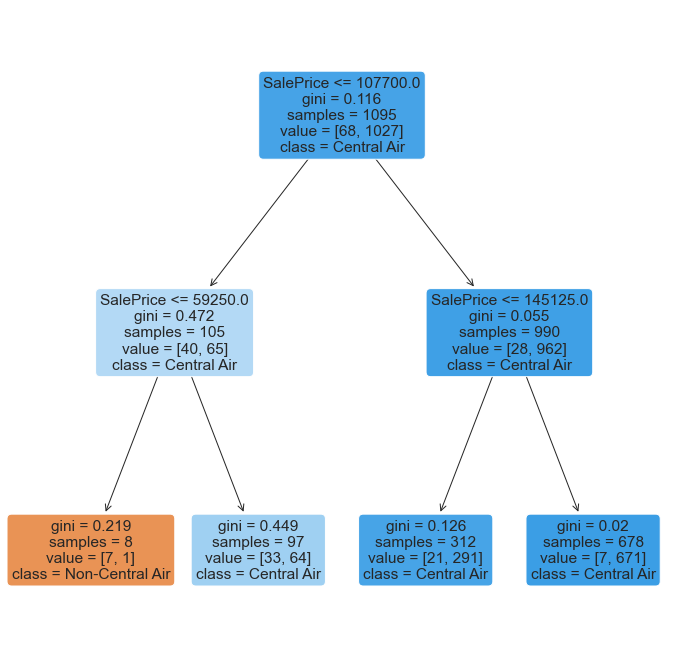

In [4]:
# Create a Decision Tree Classifier object
tree_CA_SP_d2 = DecisionTreeClassifier(max_depth = 2)

# Train the Decision Tree Classifier model
tree_CA_SP_d2.fit(X_train, y_train)

# Plot the trained Decision Tree
from sklearn.tree import plot_tree

f = plt.figure(figsize=(12,12))
plot_tree(tree_CA_SP_d2, filled=True, rounded=True, 
          feature_names=["SalePrice"], 
          class_names=["Non-Central Air","Central Air"])

[Text(321.408, 587.0880000000001, 'Sale Price <= 107700.0\ngini = 0.116\nsamples = 1095\nvalue = [68, 1027]\nclass = Central Air'),
 Text(147.312, 456.624, 'Sale Price <= 59250.0\ngini = 0.472\nsamples = 105\nvalue = [40, 65]\nclass = Central Air'),
 Text(53.568000000000005, 326.1600000000001, 'Sale Price <= 45650.0\ngini = 0.219\nsamples = 8\nvalue = [7, 1]\nclass = Non-Central Air'),
 Text(26.784000000000002, 195.69600000000003, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]\nclass = Non-Central Air'),
 Text(80.352, 195.69600000000003, 'Sale Price <= 52250.0\ngini = 0.375\nsamples = 4\nvalue = [3, 1]\nclass = Non-Central Air'),
 Text(53.568000000000005, 65.23200000000008, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = Central Air'),
 Text(107.13600000000001, 65.23200000000008, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]\nclass = Non-Central Air'),
 Text(241.056, 326.1600000000001, 'Sale Price <= 106750.0\ngini = 0.449\nsamples = 97\nvalue = [33, 64]\nclass = Central Air'),
 Text(187.488000

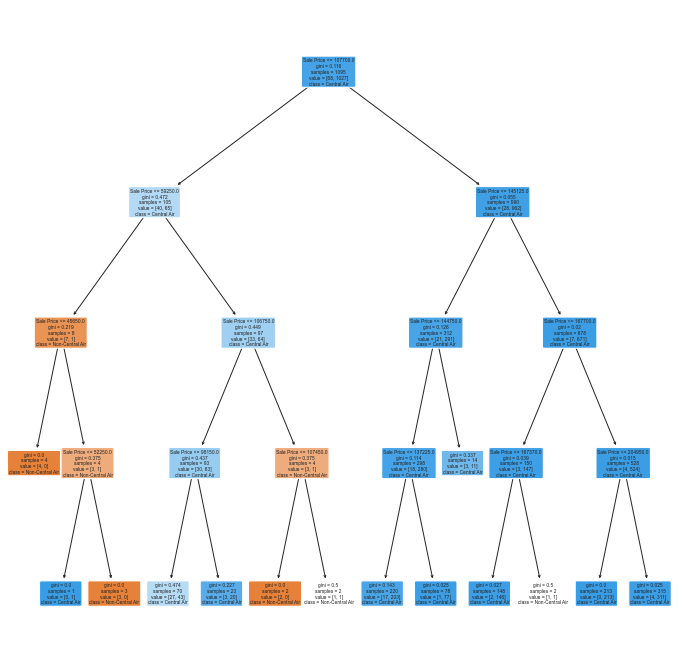

In [5]:
# Decision Tree using Train Data
tree_CA_SP_d4 = DecisionTreeClassifier(max_depth = 4)  # create the decision tree object
tree_CA_SP_d4.fit(X_train, y_train)                    # train the decision tree model

# Plot the trained Decision Tree
tree_CA_SP_d4.fit(X_train, y_train)

from sklearn.tree import plot_tree

f = plt.figure(figsize=(12,12))
plot_tree(tree_CA_SP_d4, filled=True, rounded=True, 
          feature_names=["Sale Price"], 
          class_names=["Non-Central Air","Central Air"])

# Problem 1b

**TPR = TP / (TP + FN)** : True Positive Rate = True Positives / All Positives

TNR = TN / (TN + FP) : True Negative Rate = True Negatives / All Negatives

**FPR = FP / (TN + FP)** : False Positive Rate = False Positives / All Negatives

FNR = FN / (TP + FN) : False Negative Rate = False Negatives / All Positives

For Max Depth of 2
Goodness of Fit of Model 	Train Dataset
Classification Accuracy 	: 0.94337899543379

TPR Train :	 0.9990262901655307
TNR Train :	 0.10294117647058823

FPR Train :	 0.8970588235294118
FNR Train :	 0.0009737098344693282

Goodness of Fit of Model 	Test Dataset
Classification Accuracy 	: 0.9342465753424658

TPR Test :	 1.0
TNR Test :	 0.1111111111111111

FPR Test :	 0.8888888888888888
FNR Test :	 0.0


<AxesSubplot:>

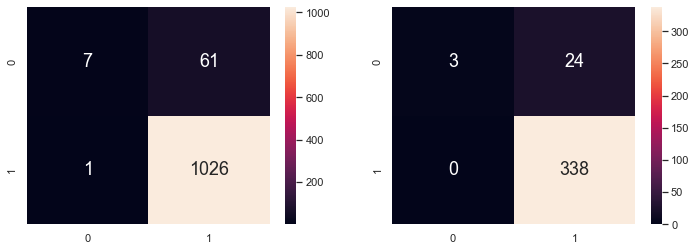

In [6]:
print("For Max Depth of 2")

# Predict CentralAir values corresponding to SalePrice
y_train_pred = tree_CA_SP_d2.predict(X_train)
y_test_pred = tree_CA_SP_d2.predict(X_test)

# Check the Goodness of Fit (on Train Data)
print("Goodness of Fit of Model \tTrain Dataset")
print("Classification Accuracy \t:", tree_CA_SP_d2.score(X_train, y_train))
print()
# Print the Accuracy Measures from the Confusion Matrix
cmTrain = confusion_matrix(y_train, y_train_pred)
tpTrain = cmTrain[1][1] # True Positives : Y (1) predicted Y (1)
fpTrain = cmTrain[0][1] # False Positives : N (0) predicted Y (1)
tnTrain = cmTrain[0][0] # True Negatives : N (0) predicted N (0)
fnTrain = cmTrain[1][0] # False Negatives : Y (1) predicted N (0)

print("TPR Train :\t", (tpTrain/(tpTrain + fnTrain)))
print("TNR Train :\t", (tnTrain/(tnTrain + fpTrain)))
print()

print("FPR Train :\t", (fpTrain/(tnTrain + fpTrain)))
print("FNR Train :\t", (fnTrain/(tpTrain + fnTrain)))
print()

# Check the Goodness of Fit (on Test Data)
print("Goodness of Fit of Model \tTest Dataset")
print("Classification Accuracy \t:", tree_CA_SP_d2.score(X_test, y_test))
print()
# Print the Accuracy Measures from the Confusion Matrix
cmTest = confusion_matrix(y_test, y_test_pred)
tpTest = cmTest[1][1] # True Positives : Y (1) predicted Y (1)
fpTest = cmTest[0][1] # False Positives : N (0) predicted Y (1)
tnTest = cmTest[0][0] # True Negatives : N (0) predicted N (0)
fnTest = cmTest[1][0] # False Negatives : Y (1) predicted N (0)

print("TPR Test :\t", (tpTest/(tpTest + fnTest)))
print("TNR Test :\t", (tnTest/(tnTest + fpTest)))
print()

print("FPR Test :\t", (fpTest/(fpTest + tnTest)))
print("FNR Test :\t", (fnTest/(fnTest + tpTest)))

# Plot the Confusion Matrix for Train and Test
f, axes = plt.subplots(1, 2, figsize=(12, 4))
sb.heatmap(confusion_matrix(y_train, y_train_pred),
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[0])
sb.heatmap(confusion_matrix(y_test, y_test_pred), 
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[1])

For Max Depth of 4
Goodness of Fit of Model 	Train Dataset
Classification Accuracy 	: 0.9461187214611873

TPR Train :	 0.9980525803310614
TNR Train :	 0.16176470588235295

FPR Train :	 0.8382352941176471
FNR Train :	 0.0019474196689386564

Goodness of Fit of Model 	Test Dataset
Classification Accuracy 	: 0.9232876712328767

TPR Test :	 0.9881656804733728
TNR Test :	 0.1111111111111111

FPR Test :	 0.8888888888888888
FNR Test :	 0.011834319526627219


<AxesSubplot:>

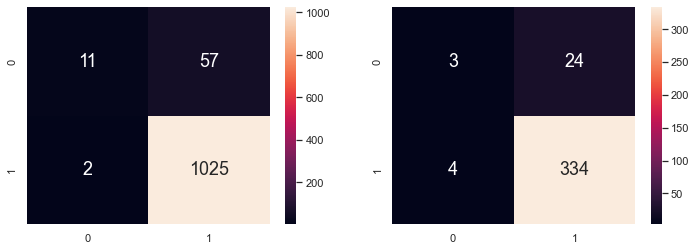

In [7]:
print("For Max Depth of 4")

# Predict CentralAir values corresponding to SalePrice
y_train_pred = tree_CA_SP_d4.predict(X_train)
y_test_pred = tree_CA_SP_d4.predict(X_test)

# Check the Goodness of Fit (on Train Data)
print("Goodness of Fit of Model \tTrain Dataset")
print("Classification Accuracy \t:", tree_CA_SP_d4.score(X_train, y_train))
print()
# Print the Accuracy Measures from the Confusion Matrix
cmTrain = confusion_matrix(y_train, y_train_pred)
tpTrain = cmTrain[1][1] # True Positives : Y (1) predicted Y (1)
fpTrain = cmTrain[0][1] # False Positives : N (0) predicted Y (1)
tnTrain = cmTrain[0][0] # True Negatives : N (0) predicted N (0)
fnTrain = cmTrain[1][0] # False Negatives : Y (1) predicted N (0)

print("TPR Train :\t", (tpTrain/(tpTrain + fnTrain)))
print("TNR Train :\t", (tnTrain/(tnTrain + fpTrain)))
print()

print("FPR Train :\t", (fpTrain/(tnTrain + fpTrain)))
print("FNR Train :\t", (fnTrain/(tpTrain + fnTrain)))
print()

# Check the Goodness of Fit (on Test Data)
print("Goodness of Fit of Model \tTest Dataset")
print("Classification Accuracy \t:", tree_CA_SP_d4.score(X_test, y_test))
print()
# Print the Accuracy Measures from the Confusion Matrix
cmTest = confusion_matrix(y_test, y_test_pred)
tpTest = cmTest[1][1] # True Positives : Y (1) predicted Y (1)
fpTest = cmTest[0][1] # False Positives : N (0) predicted Y (1)
tnTest = cmTest[0][0] # True Negatives : N (0) predicted N (0)
fnTest = cmTest[1][0] # False Negatives : Y (1) predicted N (0)

print("TPR Test :\t", (tpTest/(tpTest + fnTest)))
print("TNR Test :\t", (tnTest/(tnTest + fpTest)))
print()

print("FPR Test :\t", (fpTest/(fpTest + tnTest)))
print("FNR Test :\t", (fnTest/(fnTest + tpTest)))

# Plot the Confusion Matrix for Train and Test
f, axes = plt.subplots(1, 2, figsize=(12, 4))
sb.heatmap(confusion_matrix(y_train, y_train_pred),
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[0])
sb.heatmap(confusion_matrix(y_test, y_test_pred), 
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[1])

**Observations** : Check the confusion matrices and accuracy metrics for the two trees.

- A good model would have high accuracy, high TPR and low FPR. By this logic, Max Depth 2 (MD2) tree performs worse on the Train dataset but better in the Test dataset. In Test dataset, MD2 tree has higher TPR, accuracy and equal FPR to MD4 tree. In the Train dataset, MD4 has higher accuracy and lower FPR than MD2 tree.

- In some cases, the MD4 tree may "overfit" the train set. This means that its performance is better on Train, but not as much on Test, maybe not as good in real-life application. 

Overall, I will say the the max depth 2 tree is a better model in my case, as it performs better on both Test set.

# Problem 2a

## Central Air - Overall Quality

In [8]:
# Recall the Overall Quality - Central Air Dataset
air = pd.DataFrame(train['CentralAir'])            # Response
qual = pd.DataFrame(train['OverallQual'])           # Predictor

# Split the CentralAir-OverallQuality Dataset into Train and Test
X_train, X_test, y_train, y_test = train_test_split(qual, air, test_size = 0.25, random_state=1)

[Text(243.4909090909091, 587.0880000000001, 'Overall Quality <= 3.5\ngini = 0.116\nsamples = 1095\nvalue = [68, 1027]\nclass = Central Air'),
 Text(121.74545454545455, 456.624, 'Overall Quality <= 2.5\ngini = 0.495\nsamples = 20\nvalue = [11, 9]\nclass = Non-Central Air'),
 Text(60.872727272727275, 326.1600000000001, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]\nclass = Non-Central Air'),
 Text(182.61818181818182, 326.1600000000001, 'gini = 0.498\nsamples = 17\nvalue = [8, 9]\nclass = Central Air'),
 Text(365.23636363636365, 456.624, 'Overall Quality <= 4.5\ngini = 0.1\nsamples = 1075\nvalue = [57, 1018]\nclass = Central Air'),
 Text(304.3636363636364, 326.1600000000001, 'gini = 0.317\nsamples = 81\nvalue = [16, 65]\nclass = Central Air'),
 Text(426.1090909090909, 326.1600000000001, 'Overall Quality <= 6.5\ngini = 0.079\nsamples = 994\nvalue = [41, 953]\nclass = Central Air'),
 Text(304.3636363636364, 195.69600000000003, 'Overall Quality <= 5.5\ngini = 0.118\nsamples = 572\nvalue = [36, 53

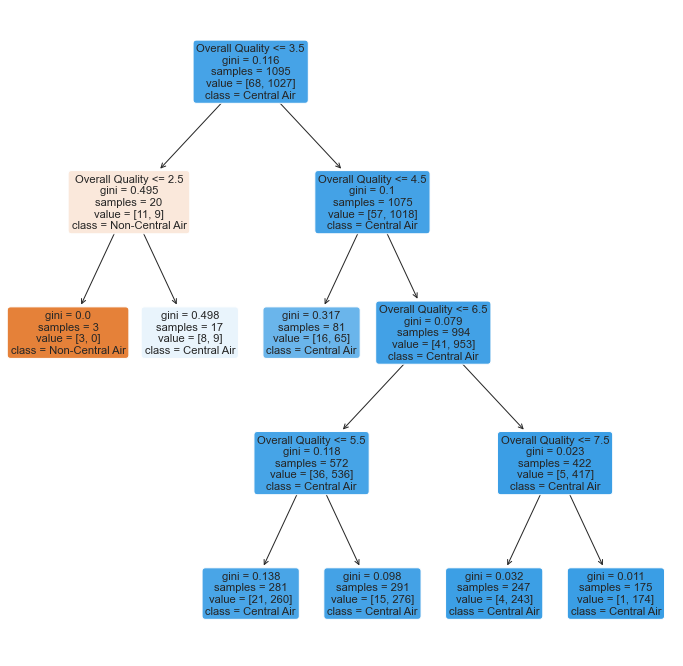

In [9]:
# Decision Tree using Train Data
tree_CA_OQ_d4 = DecisionTreeClassifier(max_depth = 4)  # create the decision tree object
tree_CA_OQ_d4.fit(X_train, y_train)                    # train the decision tree model

# Plot the trained Decision Tree
tree_CA_OQ_d4.fit(X_train, y_train)

from sklearn.tree import plot_tree

f = plt.figure(figsize=(12,12))
plot_tree(tree_CA_OQ_d4, filled=True, rounded=True, 
          feature_names=["Overall Quality"], 
          class_names=["Non-Central Air","Central Air"])

For Overall Quality - Max Depth of 4
Goodness of Fit of Model 	Train Dataset
Classification Accuracy 	: 0.9406392694063926

TPR Train :	 1.0
TNR Train :	 0.04411764705882353

FPR Train :	 0.9558823529411765
FNR Train :	 0.0

Goodness of Fit of Model 	Test Dataset
Classification Accuracy 	: 0.9315068493150684

TPR Test :	 1.0
TNR Test :	 0.07407407407407407

FPR Test :	 0.9259259259259259
FNR Test :	 0.0


<AxesSubplot:>

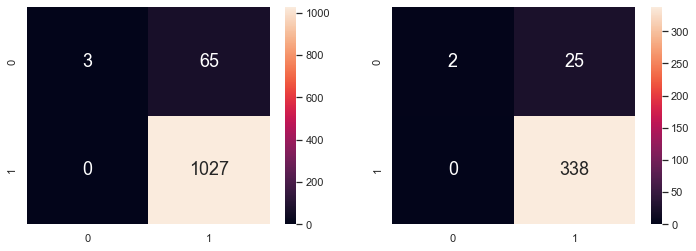

In [10]:
print("For Overall Quality - Max Depth of 4")

# Predict CentralAir values corresponding to Overall Quality
y_train_pred = tree_CA_OQ_d4.predict(X_train)
y_test_pred = tree_CA_OQ_d4.predict(X_test)

# Check the Goodness of Fit (on Train Data)
print("Goodness of Fit of Model \tTrain Dataset")
print("Classification Accuracy \t:", tree_CA_OQ_d4.score(X_train, y_train))
print()
# Print the Accuracy Measures from the Confusion Matrix
cmTrain = confusion_matrix(y_train, y_train_pred)
tpTrain = cmTrain[1][1] # True Positives : Y (1) predicted Y (1)
fpTrain = cmTrain[0][1] # False Positives : N (0) predicted Y (1)
tnTrain = cmTrain[0][0] # True Negatives : N (0) predicted N (0)
fnTrain = cmTrain[1][0] # False Negatives : Y (1) predicted N (0)

print("TPR Train :\t", (tpTrain/(tpTrain + fnTrain)))
print("TNR Train :\t", (tnTrain/(tnTrain + fpTrain)))
print()

print("FPR Train :\t", (fpTrain/(tnTrain + fpTrain)))
print("FNR Train :\t", (fnTrain/(tpTrain + fnTrain)))
print()

# Check the Goodness of Fit (on Test Data)
print("Goodness of Fit of Model \tTest Dataset")
print("Classification Accuracy \t:", tree_CA_OQ_d4.score(X_test, y_test))
print()
# Print the Accuracy Measures from the Confusion Matrix
cmTest = confusion_matrix(y_test, y_test_pred)
tpTest = cmTest[1][1] # True Positives : Y (1) predicted Y (1)
fpTest = cmTest[0][1] # False Positives : N (0) predicted Y (1)
tnTest = cmTest[0][0] # True Negatives : N (0) predicted N (0)
fnTest = cmTest[1][0] # False Negatives : Y (1) predicted N (0)

print("TPR Test :\t", (tpTest/(tpTest + fnTest)))
print("TNR Test :\t", (tnTest/(tnTest + fpTest)))
print()

print("FPR Test :\t", (fpTest/(fpTest + tnTest)))
print("FNR Test :\t", (fnTest/(fnTest + tpTest)))

# Plot the Confusion Matrix for Train and Test
f, axes = plt.subplots(1, 2, figsize=(12, 4))
sb.heatmap(confusion_matrix(y_train, y_train_pred),
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[0])
sb.heatmap(confusion_matrix(y_test, y_test_pred), 
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[1])

## Problem 2b

In [11]:
# Recall the YearBuilt. - CentralAir Dataset
air = pd.DataFrame(train['CentralAir'])            # Response
year = pd.DataFrame(train['YearBuilt'])           # Predictor

# Split the CentralAir-OverallQuality Dataset into Train and Test
X_train, X_test, y_train, y_test = train_test_split(year, air, test_size = 0.25, random_state=1)

[Text(276.21000000000004, 587.0880000000001, 'Year Built <= 1917.5\ngini = 0.116\nsamples = 1095\nvalue = [68, 1027]\nclass = Central Air'),
 Text(100.44000000000001, 456.624, 'Year Built <= 1877.5\ngini = 0.5\nsamples = 57\nvalue = [29, 28]\nclass = Non-Central Air'),
 Text(66.96000000000001, 326.1600000000001, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]\nclass = Non-Central Air'),
 Text(133.92000000000002, 326.1600000000001, 'Year Built <= 1896.5\ngini = 0.5\nsamples = 55\nvalue = [27, 28]\nclass = Central Air'),
 Text(66.96000000000001, 195.69600000000003, 'Year Built <= 1881.0\ngini = 0.346\nsamples = 9\nvalue = [2, 7]\nclass = Central Air'),
 Text(33.480000000000004, 65.23200000000008, 'gini = 0.444\nsamples = 3\nvalue = [1, 2]\nclass = Central Air'),
 Text(100.44000000000001, 65.23200000000008, 'gini = 0.278\nsamples = 6\nvalue = [1, 5]\nclass = Central Air'),
 Text(200.88000000000002, 195.69600000000003, 'Year Built <= 1913.5\ngini = 0.496\nsamples = 46\nvalue = [25, 21]\nclass = N

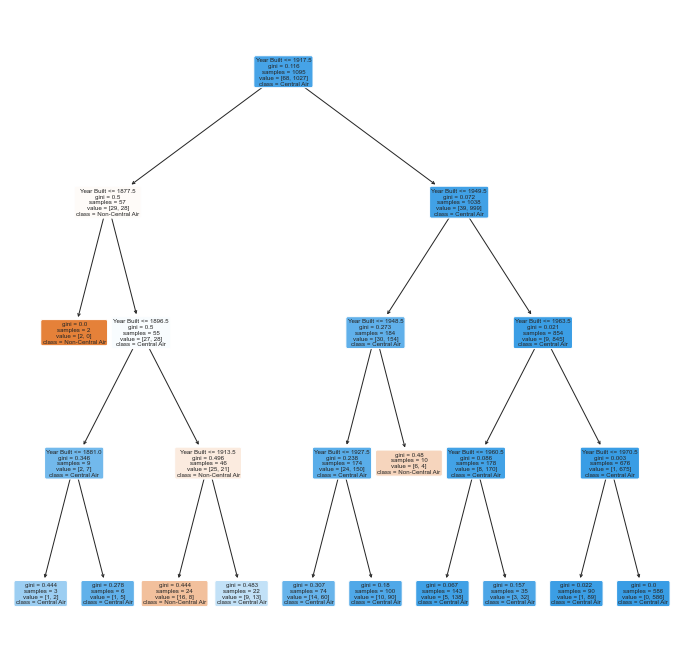

In [12]:
# Decision Tree using Train Data
tree_CA_YB_d4 = DecisionTreeClassifier(max_depth = 4)  # create the decision tree object
tree_CA_YB_d4.fit(X_train, y_train)                    # train the decision tree model

# Plot the trained Decision Tree
tree_CA_YB_d4.fit(X_train, y_train)

from sklearn.tree import plot_tree

f = plt.figure(figsize=(12,12))
plot_tree(tree_CA_YB_d4, filled=True, rounded=True, 
          feature_names=["Year Built"], 
          class_names=["Non-Central Air","Central Air"])

For Year Built - Max Depth of 4
Goodness of Fit of Model 	Train Dataset
Classification Accuracy 	: 0.9488584474885845

TPR Train :	 0.9883154819863681
TNR Train :	 0.35294117647058826

FPR Train :	 0.6470588235294118
FNR Train :	 0.011684518013631937

Goodness of Fit of Model 	Test Dataset
Classification Accuracy 	: 0.8986301369863013

TPR Test :	 0.9615384615384616
TNR Test :	 0.1111111111111111

FPR Test :	 0.8888888888888888
FNR Test :	 0.038461538461538464


<AxesSubplot:>

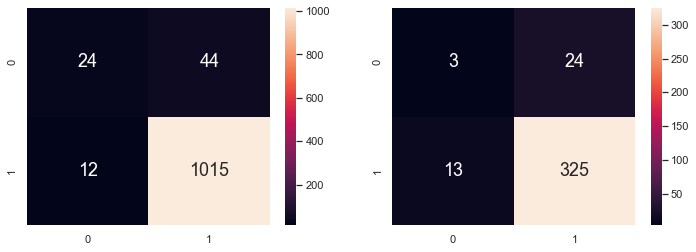

In [13]:
print("For Year Built - Max Depth of 4")

# Predict CentralAir values corresponding to Overall Quality
y_train_pred = tree_CA_YB_d4.predict(X_train)
y_test_pred = tree_CA_YB_d4.predict(X_test)

# Check the Goodness of Fit (on Train Data)
print("Goodness of Fit of Model \tTrain Dataset")
print("Classification Accuracy \t:", tree_CA_YB_d4.score(X_train, y_train))
print()
# Print the Accuracy Measures from the Confusion Matrix
cmTrain = confusion_matrix(y_train, y_train_pred)
tpTrain = cmTrain[1][1] # True Positives : Y (1) predicted Y (1)
fpTrain = cmTrain[0][1] # False Positives : N (0) predicted Y (1)
tnTrain = cmTrain[0][0] # True Negatives : N (0) predicted N (0)
fnTrain = cmTrain[1][0] # False Negatives : Y (1) predicted N (0)

print("TPR Train :\t", (tpTrain/(tpTrain + fnTrain)))
print("TNR Train :\t", (tnTrain/(tnTrain + fpTrain)))
print()

print("FPR Train :\t", (fpTrain/(tnTrain + fpTrain)))
print("FNR Train :\t", (fnTrain/(tpTrain + fnTrain)))
print()

# Check the Goodness of Fit (on Test Data)
print("Goodness of Fit of Model \tTest Dataset")
print("Classification Accuracy \t:", tree_CA_YB_d4.score(X_test, y_test))
print()
# Print the Accuracy Measures from the Confusion Matrix
cmTest = confusion_matrix(y_test, y_test_pred)
tpTest = cmTest[1][1] # True Positives : Y (1) predicted Y (1)
fpTest = cmTest[0][1] # False Positives : N (0) predicted Y (1)
tnTest = cmTest[0][0] # True Negatives : N (0) predicted N (0)
fnTest = cmTest[1][0] # False Negatives : Y (1) predicted N (0)

print("TPR Test :\t", (tpTest/(tpTest + fnTest)))
print("TNR Test :\t", (tnTest/(tnTest + fpTest)))
print()

print("FPR Test :\t", (fpTest/(fpTest + tnTest)))
print("FNR Test :\t", (fnTest/(fnTest + tpTest)))

# Plot the Confusion Matrix for Train and Test
f, axes = plt.subplots(1, 2, figsize=(12, 4))
sb.heatmap(confusion_matrix(y_train, y_train_pred),
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[0])
sb.heatmap(confusion_matrix(y_test, y_test_pred), 
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[1])

**Observations** : Check the confusion matrices and accuracy metrics for the two trees.

- A good model would have high accuracy, high TPR and low FPR. By this logic, both trees perform equally well.
- In Train, Year Built has higher accuracy and lower FPR, so it performs better than Overall Quality. In Test, Overall Quality has higher accuracy and higher TPR than Year Built.
- If TPR is a more important metric than FPR, Overall Quality will be the better tree, and vice versa.

Overall, I will say the the Year Built tree is a better model, as I think FPR is a more important metric. This is because TPR for Overall Quality is a perfect TPR = 1.0, which is too ideal.

# Problem 3a

In [14]:
# Import Decision Tree Classifier model from Scikit-Learn
from sklearn.tree import DecisionTreeClassifier

# Create a Decision Tree Classifier object
# you can change the max_depth as you wish

# Decision Tree with max depth = 4
tree_CA_SP_d4 = DecisionTreeClassifier(max_depth = 4)

In [15]:
# Import the required function from sklearn
from sklearn.model_selection import train_test_split

# Extract Response and Predictors
y = pd.DataFrame(train['CentralAir'])
X = pd.DataFrame(train['SalePrice'])

# Split the Dataset into random Train and Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

# Check the sample sizes
print("Train Set :", X_train.shape, y_train.shape)
print("Test Set  :", X_test.shape, y_test.shape)

Train Set : (1168, 1) (1168, 1)
Test Set  : (292, 1) (292, 1)


[Text(1243.5428571428572, 1174.1760000000002, 'SalePrice <= 98150.0\ngini = 0.123\nsamples = 1168\nvalue = [77, 1091]\nclass = Central Air'),
 Text(637.7142857142858, 913.248, 'SalePrice <= 61691.5\ngini = 0.494\nsamples = 88\nvalue = [39, 49]\nclass = Central Air'),
 Text(255.0857142857143, 652.3200000000002, 'SalePrice <= 46000.0\ngini = 0.26\nsamples = 13\nvalue = [11, 2]\nclass = Non-Central Air'),
 Text(127.54285714285714, 391.39200000000005, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]\nclass = Non-Central Air'),
 Text(382.62857142857143, 391.39200000000005, 'SalePrice <= 52250.0\ngini = 0.375\nsamples = 8\nvalue = [6, 2]\nclass = Non-Central Air'),
 Text(255.0857142857143, 130.46400000000017, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = Central Air'),
 Text(510.1714285714286, 130.46400000000017, 'gini = 0.245\nsamples = 7\nvalue = [6, 1]\nclass = Non-Central Air'),
 Text(1020.3428571428572, 652.3200000000002, 'SalePrice <= 97750.0\ngini = 0.468\nsamples = 75\nvalue = [28, 47]\n

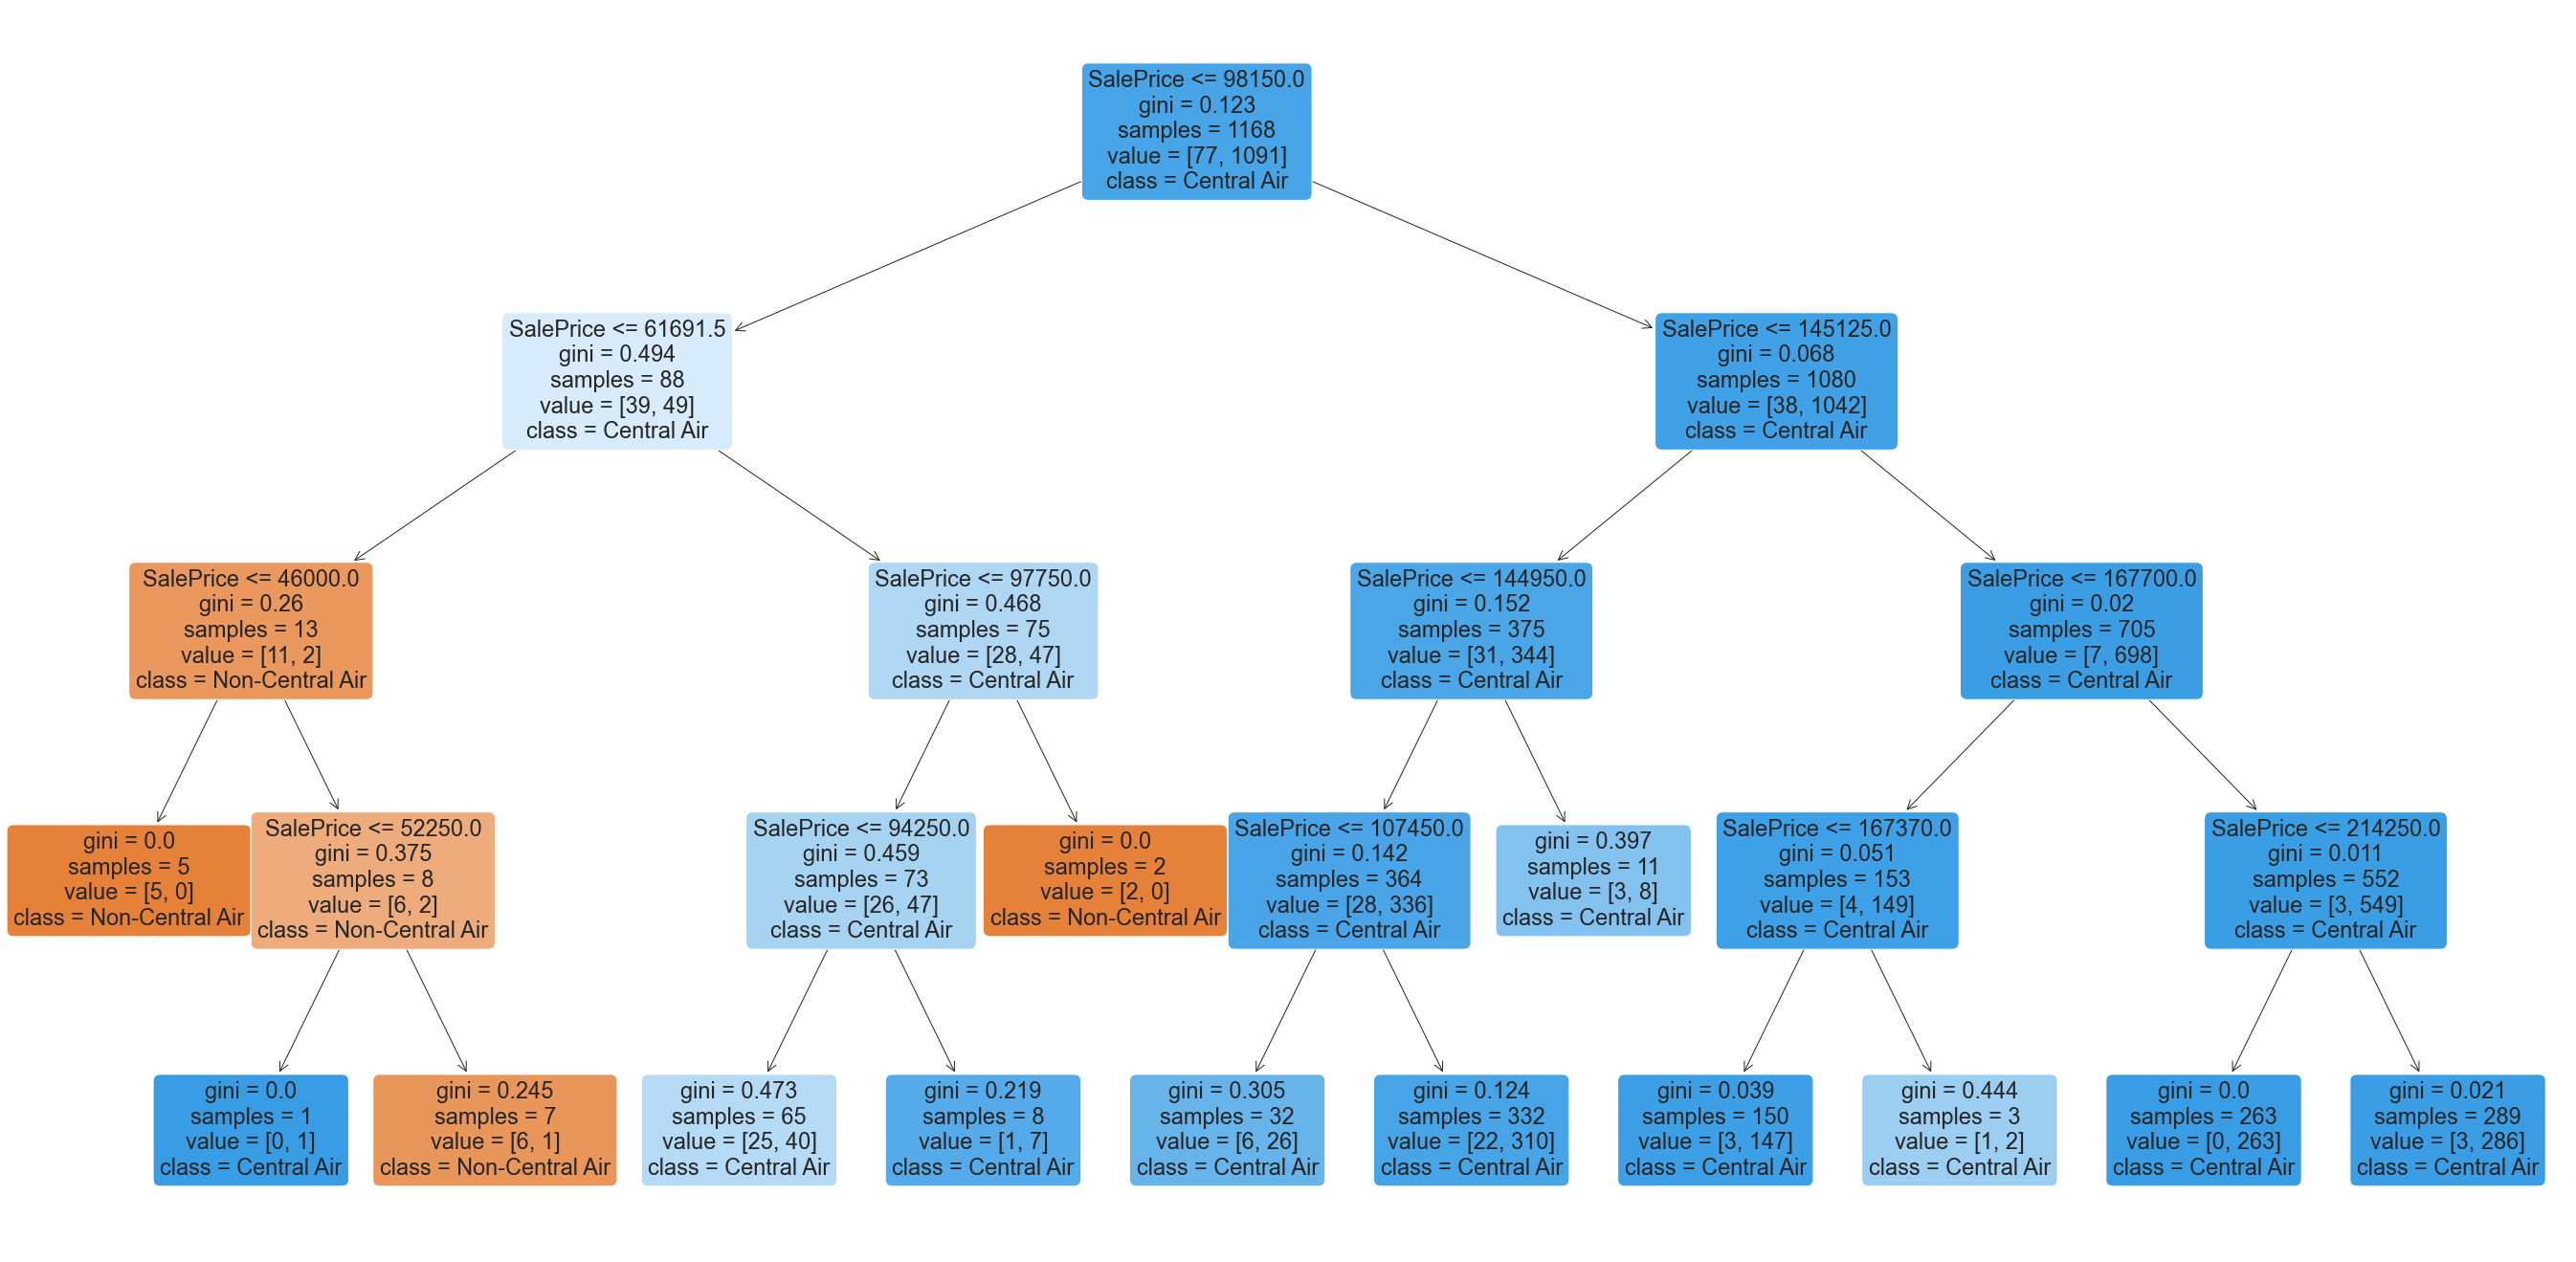

In [16]:
# Fit the tree with max depth 4
tree_CA_SP_d4.fit(X_train, y_train)

# Plot the tree with max depth 4
from sklearn.tree import plot_tree

f = plt.figure(figsize=(48,24))
plot_tree(tree_CA_SP_d4, filled=True, rounded=True, 
          feature_names=X_train.columns, 
          class_names=["Non-Central Air","Central Air"])

**Observation** : Take a close look at the tree you printed above (open the image in a new tab, or download the image for a closer inspection, if needed).

- class = CentralAir = True. Thus, False Positive will mean the Negative (CentralAir = False) cases that end up in a leaf node that predicts class = CentralAir. We do not need to look at nodes that predict class = N. Hence, we only look at blue nodes.
-  In any leaf node that predicts class = Y, the first number is the bracket counts the Negative samples.
- Thus, we only need to take a look at the leaf nodes that predict class = Y (blue in color), and within those nodes, we only need to check the first number to know the Negatives classified as Y, that is, the False Positives.

In my case, as above, the blue leaf node (class = Central Air) that has the highest first number (FP) is the fifth leaf at level 4. It has 286data points (samples) in it, with 26 Negatives and 260Positives.

## Condition to reach that leaf node is 98150.0 < SP <= 137950.0


In [17]:
train2 = pd.DataFrame()
#house_data_fil = pd.DataFrame(y_train)
train2['SalePrice']=X_train
train2['CentralAir']=y_train
train2

,SalePrice,CentralAir
1366,193000,Y
574,139000,Y
952,133900,Y
452,204000,Y
841,157500,Y
...,...,...
110,136900,Y
1364,144152,Y
490,115000,Y
70,244000,Y


In [22]:
train2 = train2[train2['SalePrice'] > 98150.0]
train2 = train2[train2['SalePrice'] <= 137950.0]

In [23]:
display = train2[train2['CentralAir'] == "N"]
display

,SalePrice,CentralAir
74,107400,N
870,109500,N
896,106500,N
108,115000,N
418,126000,N
246,137000,N
713,129000,N
93,133900,N
291,135900,N
1248,129500,N


In [21]:
display.shape

(26, 2)